# Social Media Mental Health Indicators Dataset

This CSV dataset records annual circulation statistics and bibliographic metadata for prints films in the Toulouse public library collection. It is intended for analysis of lending trends, collection management, patron behavior, and media-use research.

Column Description:

- person_name:	Name or identifier of the person.
- age:	Age of the individual in years.
- date:	The date on which the data was recorded.
- gender:	Gender of the user (Male, Female, Other).
- platform:	Primary social media platform the person uses.
- daily_screen_time_min:	Total daily device screen time in minutes.
- social_media_time_min:	Total time spent on social media in minutes per day.
- negative_interactions_count:	Number of negative or harmful interactions experienced online.
- positive_interactions_count:	Number of positive or supportive interactions experienced online.
- sleep_hours:	Total number of hours the person sleeps per day.

In [271]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
url = "https://raw.githubusercontent.com/SeaJayEm/docs_formation/refs/heads/main/mental_health_social_media_dataset.csv"
df = pd.read_csv(url)
df.head()

,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,Reyansh Ghosh,35,1/1/2024,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed
1,Neha Patel,24,1/12/2024,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed
2,Ananya Naidu,26,1/6/2024,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed
3,Neha Das,66,1/17/2024,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed
4,Reyansh Banerjee,31,1/28/2024,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed


# EDA

Affichez un échantillon de 10 lignes du dataframe.

In [251]:
# ============================================================
# 📌 J'affiche un echantillon de 10 lignes grace a sample()
# ============================================================

df.sample(10)

,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
2129,Myra Reddy,22,6/10/2024,Female,TikTok,444,289,2,3,6.8,16,4,9,4,Stressed
2881,Navya Patil,39,10/6/2024,Male,Snapchat,214,118,0,1,7.9,39,2,6,6,Stressed
4319,Diya Kale,20,2/2/2025,Male,TikTok,474,308,2,3,6.6,13,4,9,4,Stressed
2104,Riya Mishra,62,4/4/2024,Female,Facebook,190,66,0,1,8.0,41,1,5,7,Healthy
1369,Jiya Das,45,9/26/2025,Female,Facebook,220,77,0,1,7.9,38,1,5,7,Healthy
3037,Aditi Ansari,24,7/6/2025,Male,TikTok,505,328,2,3,6.5,10,4,9,4,Stressed
811,Aarav Naidu,14,9/10/2024,Male,WhatsApp,417,104,0,1,6.9,18,2,7,6,Stressed
4936,Kavya Das,58,10/9/2024,Female,Snapchat,166,91,0,1,8.2,43,2,6,6,Stressed
2130,Kavya Joshi,31,5/24/2024,Male,YouTube,335,201,1,3,7.3,26,3,7,6,Stressed
4114,Sai Verma,21,10/26/2025,Male,TikTok,444,289,2,3,6.8,16,4,9,4,Stressed


Décrivez le dataset et commentez ce que vous constatez d'intéressant.

In [252]:
# ============================================================
# 📌 Description du dataset, j'utilise la fonction quickexplore
# pour mieux comprendre les types de données
# ============================================================

def quick_explore(dataframe):
    """Exploration rapide d'un DataFrame"""
    print('##### Observer les lignes #####')
    display(dataframe.head(10))
    print('\n')

    print('##### Dimensions du dataset #####')
    print(f'Lignes : {dataframe.shape[0]}, Colonnes : {dataframe.shape[1]}')
    print('\n')

    print('##### Informations sur les colonnes #####')
    print(dataframe.info())
    print('\n')

    print('##### Noms des colonnes #####')
    print(list(dataframe.columns))
    print('\n')

    print('##### Valeurs uniques #####')
    print(dataframe.nunique())
    print('\n')

    print('##### Description des colonnes numériques #####')
    stats = dataframe.describe(percentiles=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]).T
    print(stats.to_markdown())
    print('\n')

    print('##### Pourcentage de NaN par colonne #####')
    nan_percentage = (dataframe.isnull().sum() / len(dataframe)) * 100
    only_nan  = nan_percentage[nan_percentage > 0].sort_values(ascending=False)
    print(only_nan)
    print('\n')

    print('##### Nombre de doublons #####')
    print(dataframe.duplicated().sum(), 'doublon(s) trouvé(s)')
    print('\n')

    print('##### NaN par colonne #####')
    print(dataframe.isna().sum())

quick_explore(df)

##### Observer les lignes #####


,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,Reyansh Ghosh,35,1/1/2024,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed
1,Neha Patel,24,1/12/2024,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed
2,Ananya Naidu,26,1/6/2024,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed
3,Neha Das,66,1/17/2024,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed
4,Reyansh Banerjee,31,1/28/2024,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed
5,Myra Kale,25,2/8/2024,Female,Snapchat,516,284,1,3,6.4,8,3,8,5,Stressed
6,Ananya Kulkarni,29,2/19/2024,Other,Snapchat,328,180,1,2,7.4,27,3,7,6,Stressed
7,Meera Das,28,1/11/2024,Female,Facebook,394,138,1,1,7.0,21,2,7,6,Stressed
8,Vihaan Naidu,31,1/22/2024,Male,Facebook,326,114,0,1,7.4,27,2,6,6,Stressed
9,Meera Patil,26,2/2/2024,Female,Facebook,339,119,0,1,7.3,26,2,6,6,Stressed




##### Dimensions du dataset #####
Lignes : 5000, Colonnes : 15


##### Informations sur les colonnes #####
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_name                  5000 non-null   str    
 1   age                          5000 non-null   int64  
 2   date                         5000 non-null   str    
 3   gender                       5000 non-null   str    
 4   platform                     5000 non-null   str    
 5   daily_screen_time_min        5000 non-null   int64  
 6   social_media_time_min        5000 non-null   int64  
 7   negative_interactions_count  5000 non-null   int64  
 8   positive_interactions_count  5000 non-null   int64  
 9   sleep_hours                  5000 non-null   float64
 10  physical_activity_min        5000 non-null   int64  
 11  anxiety_level                5000 no

Commentaire : C'est un dataset a propos du temps que passent un panel de gens sur les reseaux sociaux, il y a plusieurs reseaux sociaux, des gens de tout age.
Nous avons aussi leurs interactions positives ou negatives, le nombre d'heures de sommeil, leur activité phyisique, le niveau d'anxiété, de stress, leur humeur et leur etat mental. On peut donc imaginer que ca doit traiter de l'impact des reseaux sociaux sur le quotidien des gens.

Affichez le nombre de lignes.

In [253]:
# ============================================================
# 📌 J'affiche le nombre de lignes
# ============================================================

print(f'Le dataset contient {len(df)} lignes')

Le dataset contient 5000 lignes


Affichez le nombre de colonnes.

In [254]:
# ============================================================
# 📌 J'affiche le nombre de colonnes
# ============================================================

print(f'Le nombre de colonnes est {df.shape[1]}')

Le nombre de colonnes est 15


Affichez la répartition en pourcentage des genres et des plateformes.

In [255]:
# ============================================================
# 📌 J'affiche la repartition en pourcentage
# des genres et des plateformes
# ============================================================

display(df['gender'].value_counts(normalize=True) * 100)
# Il y a 49.48% de femmes, 48.54% d'hommes et 1.98% d'autres genres dans le dataset

display(df['platform'].value_counts(normalize=True) * 100)
# Pour les plateforme, c'est très bien reparti avec environ 14% pour chacune des 7 plateformes présentes dans la colonne

gender
Female    49.48
Male      48.54
Other      1.98
Name: proportion, dtype: float64

platform
Facebook     14.88
TikTok       14.46
YouTube      14.32
WhatsApp     14.20
Snapchat     14.10
Instagram    14.06
Twitter      13.98
Name: proportion, dtype: float64

# Data viz et relations entre variables

Créez une matrice de corrélations entre les données numériques du dataset. Que constatez-vous ?

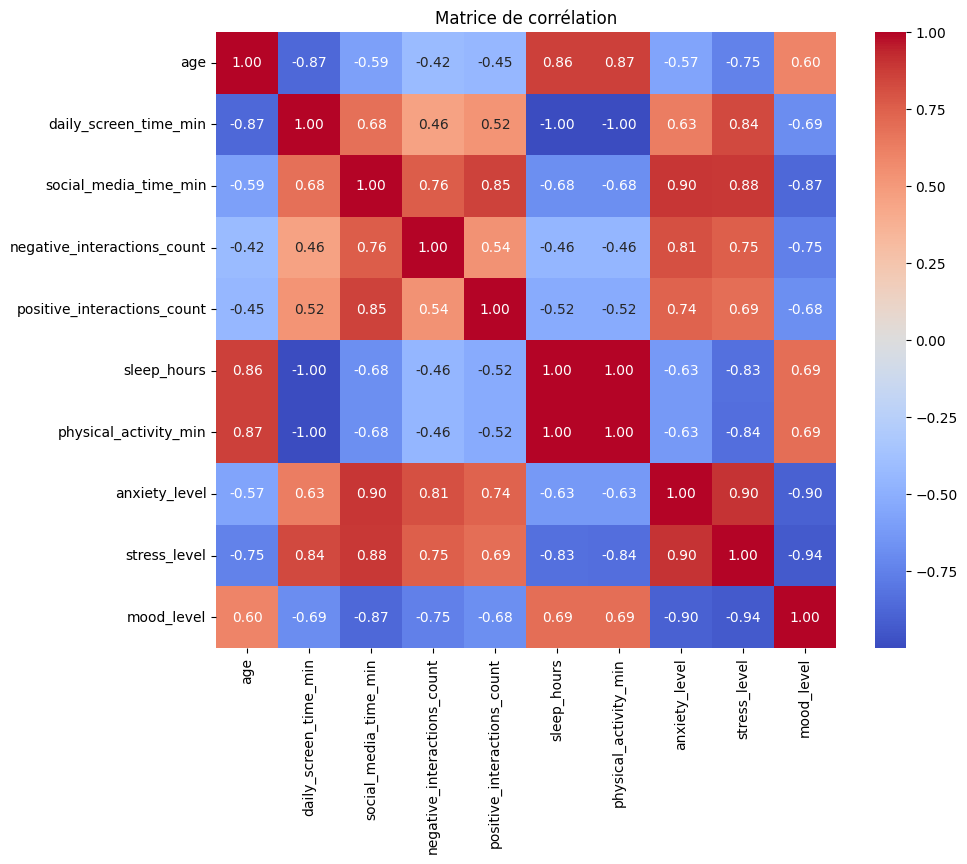

In [256]:
# ============================================================
# 📌 Je crée une matrice de corrélation entre les données numériques
# ============================================================

# Je crée un nouveau dataset avec uniquement les valeurs numeriques
df_num = df.drop(columns=['person_name', 'date', 'gender', 'platform', 'mental_state'])

matrice_corr = df_num.corr()

# sns_heatmap : Matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(df_num.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matrice de corrélation')
plt.show()


Commentaire : Je constate qu'il y a enormement de corrélation qu'elles soient négatives ou positives, et beaucoup d'entre elles sont fortes par exemple on a du coefficient de correlation positif a 0.90. Dans les coefficient de correlation negatif, on a aussi du -0.94. En résumé, on remarque qu'il a beaucoup de corrélation entre toutes les variables, ce qui démontre que les variables influent les unes sur les autres à travers cette heatmap.

Visualisez la relation entre social_media_time_min et sleep_hours. Que constatez-vous ?

Commentaire : Entre le temps passé sur les reseaux sociaux et le nombre d'heure de sommeil il y a une corrélation négative modérement forte, les deux variables evoluent dans le sens opposé. Cela signifie que plus je dors, moins je passe d'heure sur les reseaux sociaux.

Visualisez la distribution de daily_screen_time_min,	social_media_time_min, sleep_hours, et	physical_activity_min	dans 4 boxplots (dans la même figure) et analysez.

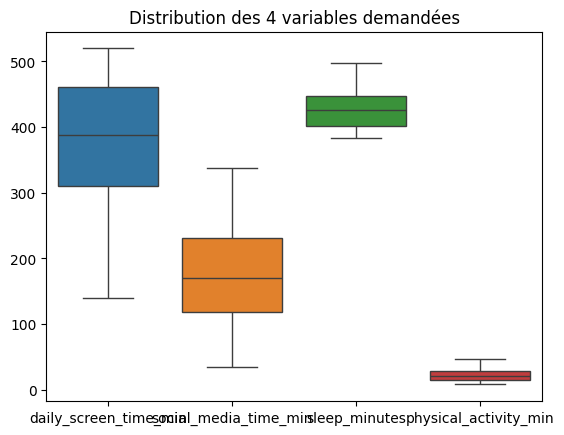

In [257]:
# ============================================================
# 📌 Je fais 4 boxplots dans la même figure qui vont analyser
# le temps d'ecran par jour, le temps passé sur les reseaux
# sociaux par jour, les heures de sommeil et l'activité physique
# ============================================================

# Je convertis ma colonne sleep_hours en minutes
df['sleep_minutes'] = df['sleep_hours'] * 60

# Je crée une liste qui rassemble toutes mes colonnes
liste = df[['daily_screen_time_min', 'social_media_time_min', 'sleep_minutes', 'physical_activity_min']]

# sns_boxplot : Visualise la distribution + outliers
sns.boxplot(data=liste)
plt.title('Distribution des 4 variables demandées')
plt.show()



Commentaire : On constate qu'il y a un temps d'ecran qui se situe pour la majorité entre 300 et plus de 500 minutes par jour. Le temps sur les reseaux sociaux est pour plus de 75% des gens au dela de 100 minutes et monte jusqu'a plus de 300 minutes par jour. Le temps de sommeil est pour 75% des gens inférieur a 450 minutes (7h30), ce qui est plutot dans la norme recommandée. En revanche, il y a très peu d'activité physique par jour. La majeure partie des gens passent beaucoup de temps sur leur ecran, ainsi que sur les reseaux sociaux, dorment en moyenne un nombre d'heure correct et font peu d'activité physique.

# Analyse de comportements

Quelles sont les noms des 3 personnes qui passent le plus de temps sur Instagram, et combien de temps passent-elles dessus?

In [258]:
# ============================================================
# 📌 J'affiche les 3 personnes qui passent le plus de temps sur Instagram
# ============================================================

insta = df['platform'] == 'Instagram'
df_insta = df[insta].sort_values('social_media_time_min', ascending=False)
df_insta.head()

# Les 3 personnes qui passent le plus de temps sur intagram sont Suhani Patel, Navya Mishra, Vivaan Reddy et à égalité Krishna Rathod avec 260 minutes par jour

,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state,sleep_minutes
1033,Suhani Patel,19,1/30/2024,Male,Instagram,519,260,1,3,6.4,8,3,8,5,Stressed,384.0
374,Navya Mishra,25,5/8/2024,Female,Instagram,520,260,1,3,6.4,8,3,8,5,Stressed,384.0
1598,Vivaan Reddy,23,3/17/2025,Female,Instagram,519,260,1,3,6.4,8,3,8,5,Stressed,384.0
1525,Krishna Rathod,24,9/23/2024,Female,Instagram,520,260,1,3,6.4,8,3,8,5,Stressed,384.0
1435,Neha Patel,21,3/8/2024,Male,Instagram,518,259,1,3,6.4,8,3,8,5,Stressed,384.0


Créez deux nouvelles colonnes calculant le nombre d'interactions positives / négatives par heure passée sur le réseau social. Quel est le réseau sur lequel les utilisateurs vivent en moyenne le plus d'ineractions positives / négatives par heure passée dessus ?

In [259]:
# ============================================================
# 📌 Création de deux colonnes qui calculent le nombre d'interactions
# positives par heure passée sur le reseau et le nombre d'interactions
# négatives par heure passée sur le reseau social
# ============================================================

# Je crée ma colonne pour les intéractions positives
df['int_pos'] = (df['positive_interactions_count'] / (df['social_media_time_min'] / 60)).round(2)
df.head()

# Je crée ma colonne pour les intéractions négatives
df['int_neg'] = (df['negative_interactions_count'] / (df['social_media_time_min'] / 60)).round(2)
display(df.head())

# Je crée un nouveau df qui garde les colonnes qui m'intéressent
df_reseau_int = df[['platform', 'int_pos', 'int_neg']]

# J'utilise groupby pour regrouper par plateforme en faisant la moyenne pour chaque colonne par plateforme
df_reseau_moyenne = df_reseau_int.groupby(by='platform').mean().round(2)

# Je classe les interactions positives par heures par reseau, ici c'est Youtube qui ont le plus d'interactions positives par heure
display(df_reseau_moyenne.sort_values('int_pos', ascending=False))

# Je classe les interactions negatives par heures par reseau, ici c'est TikTok qui ont le plus d'interactions negatives par heure
display(df_reseau_moyenne.sort_values('int_neg', ascending=False))

,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state,sleep_minutes,int_pos,int_neg
0,Reyansh Ghosh,35,1/1/2024,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed,444.0,0.75,0.38
1,Neha Patel,24,1/12/2024,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed,402.0,0.80,0.27
2,Ananya Naidu,26,1/6/2024,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed,432.0,0.61,0.31
3,Neha Das,66,1/17/2024,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed,480.0,0.57,0.00
4,Reyansh Banerjee,31,1/28/2024,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed,426.0,0.57,0.28


,int_pos,int_neg
platform,,
YouTube,0.82,0.26
Instagram,0.78,0.25
Twitter,0.58,0.39
Snapchat,0.54,0.24
Facebook,0.54,0.27
WhatsApp,0.54,0.09
TikTok,0.53,0.42


,int_pos,int_neg
platform,,
TikTok,0.53,0.42
Twitter,0.58,0.39
Facebook,0.54,0.27
YouTube,0.82,0.26
Instagram,0.78,0.25
Snapchat,0.54,0.24
WhatsApp,0.54,0.09


Créez une colonne qui contient '-1' si la personne a vécu plus d'interactions négatives, '0' si la personne a vécu autant d'interactions négatives que positives et '1' si la personne a vécu plus d'interactions positives, et affichez le compte de chaque 'sentiment'.

In [260]:
# ============================================================
# 📌 Création d'une nouvelle colonne ou il y aura "-1" si la personne
# a vécu plus d'interactions négatives, "0" si la personne en a vécu autant
# et "1" si la personne a vecu plus d'interactions positives
# ============================================================

# Je crée ma fonction avec les conditions
def sentiment(ligne):
    if ligne['negative_interactions_count'] > ligne['positive_interactions_count']:
        return -1
    elif ligne['negative_interactions_count'] < ligne['positive_interactions_count']:
        return 1
    elif ligne['negative_interactions_count'] == ligne['positive_interactions_count']:
        return 0
    
# Je crée ma nouvelle colonne sentiment, j'utilise ma fonciton dessus avec apply pour que ca itère sur chaque ligne grace a axis = 1
df['sentiment'] = df.apply(sentiment, axis=1)

display(df.head())

df.value_counts('sentiment')

# Il y a 3602 personnes qui ont vécu plus d'interactions positives, 1398 qui ont vécu autant de l'une que de l'autre.


,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state,sleep_minutes,int_pos,int_neg,sentiment
0,Reyansh Ghosh,35,1/1/2024,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed,444.0,0.75,0.38,1
1,Neha Patel,24,1/12/2024,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed,402.0,0.80,0.27,1
2,Ananya Naidu,26,1/6/2024,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed,432.0,0.61,0.31,1
3,Neha Das,66,1/17/2024,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed,480.0,0.57,0.00,1
4,Reyansh Banerjee,31,1/28/2024,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed,426.0,0.57,0.28,1


sentiment
1    3602
0    1398
Name: count, dtype: int64

# Typologie des plateformes

1. Créez une matrice de features avec : ['age', 'daily_screen_time_min', 'social_media_time_min', 'negative_interactions_count', 'positive_interactions_count', 'sleep_hours', 'physical_activity_min', 'anxiety_level', 'stress_level', 'mood_level', 'neg_per_hour'].

2. Utilisez un modèle de classification avec KNN pour prédire la pletforme utilisée grâce à ces features.

3. Evaluez le modèle avec le score adapté, un rapport de classification, et une matrice de confusion. Interpretez vos résultats.

4. Est ce qu'il y a good fitting ?

5. Vulgarisez le fonctionnement du modele utilisé.


In [261]:
# 1. Je crée ma matrice de features

features = ['age', 'daily_screen_time_min', 'negative_interactions_count', 'positive_interactions_count', 'sleep_hours', 'physical_activity_min', 'anxiety_level', 'stress_level', 'mood_level', 'int_neg']
X = df[features]

In [262]:
# 2. J'utilise un modele de classification KNN

# Je définis ma cible
y = df['platform']

# Je sépare mes données en deux ensembles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

# Je standardise mes données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# J'instancie mon modèle
model = KNeighborsClassifier()

# J'entraine mon modèle
model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [263]:
# 3. J'effectue mes prédictions

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

print(f"Accuracy score train : {accuracy_train:.2f}")
print(f"Accuracy score test : {accuracy_test:.2f}")

Accuracy score train : 0.97
Accuracy score test : 0.94


In [264]:
# Je fais un rapport de classification 

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

    Facebook       0.90      0.93      0.91       151
   Instagram       0.89      0.92      0.91       140
    Snapchat       0.90      0.91      0.90       117
      TikTok       1.00      1.00      1.00       150
     Twitter       0.96      0.94      0.95       141
    WhatsApp       0.96      0.94      0.95       165
     YouTube       0.97      0.94      0.96       136

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



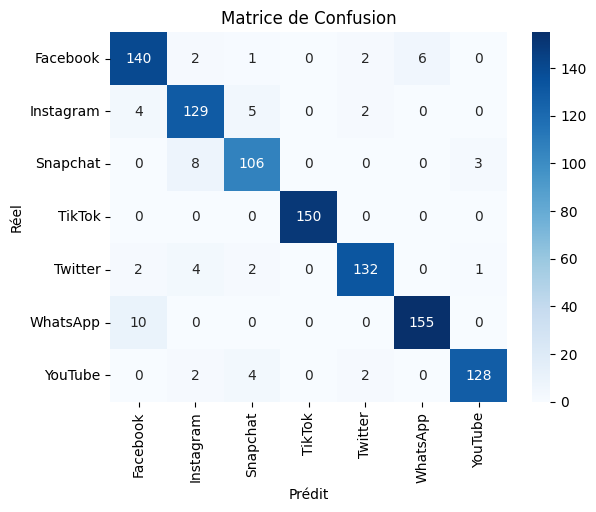

In [265]:
# Je fais une matrice de confusion

def matrice_confusion(y_test, y_pred):
    """
    Afficher la matrice de confusion
    Avec labels : matrice_confusion(y_test, y_pred, labels=['Non', 'Oui'])
    """
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.title('Matrice de Confusion')
    plt.show()

matrice_confusion(y_test, y_test_pred)

# La diagonale représente les bonnes prédictions
# Pour Facebook en ligne on peut dire que 140 predictions etaient bonne, 2 utilisaient instagram et aussi twitter, 1 utilisait snapchat, 6 whatsapp et aucun pour tiktok et youtube
# Pour Facebook en colonne on peut dire que 140 predictions etaient bonnes, 10 on été prédit facebook alors que c'etait wwhatsapp, 2 twitter et 4 instagram predit facebook alors 
# que c'était twitter et instagram respectivement

In [266]:
# 4. Il y a un good fitting car les accuracy score sont très hauts et proches 0.97 et 0.94, il n'y a que 0.3 d'ecart

In [267]:
# 5. Pour vulgariser le KNN, on prend les features d'une personne et on regarde avec ses voisins qui a le plus de similarités avec cette personne. En fonction de cela,
# nous pourrons dire quelle plateforme la personne utilise. Plus les features des personnes entre elles ont des features correspondantes, plus il y a
# de chances pour que ces personnes la appartiennent a cette plateforme. Par exemple, si une personne dort 8h, fait 30min d'activité sportive par jour,
# a 350min de temps d'ecran par jour, une anxiété a 7 etc. et que ces caracatéristiques de ces features correspondent a d'autres personnes, alors elle a de grandes chances 
# d'utiliser la meme plateforme. Dans le cas contraire elle aurait plus de chances d'utiliser une autre plateforme que ses voisins.

# Prédiction du niveau d'anxiété (régression linéaire)

1. Construisez un modèle de régression linéaire utilisant 'daily_screen_time_min','social_media_time_min', 'physical_activity_min', 'negative_interactions_count','positive_interactions_count', et 'sleep_hours' pour prédire la niveau d'anxiété de chaque utilisateur. N'oubliez pas de standardiser vos données.
2. Évaluez les performances de votre modele grace a la metrique adaptée et la MAE et interpretez le resultat.
3. Est ce qu'il y a good fitting ?
4. Vulgarisez le fonctionnement du modele utilisé.

In [268]:
# 1. Je construis un modèle de régression linéaire

# Je crée mes variables X et y 

X  = df[['daily_screen_time_min', 'social_media_time_min', 'physical_activity_min', 'negative_interactions_count', 'positive_interactions_count', 'sleep_hours']]
y = df['anxiety_level']

# Je sépare mes données en deux ensembles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

# Je standardise mes données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# J'instancie mon modèle
model = LinearRegression()

# J'entraine mon modèle
model.fit(X_train_scaled, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# 2. J'evalue les performances de mon modèle :

r2_train = r2_score(y_train, y_train_pred) # TOUJOURS y_true, Y_pred
r2_test = r2_score(y_test, y_test_pred)

print(f"R2 Score sur l'ensemble d'entraînement: {r2_train:.2f}")
print(f"R2 Score sur l'ensemble de test: {r2_test:.2f}")

R2 Score sur l'ensemble d'entraînement: 0.84
R2 Score sur l'ensemble de test: 0.85


In [273]:
# La MAE (l'erreur moyenne)

mae = mean_absolute_error(y_test, y_test_pred)
print(mae)

0.28091349101420804


In [ ]:
# Interprétation avec le R2_score et la MAE + good fitting ?

# Le R2_score montre que les données d'entrainement et les données de test sont très proches a 0.1 près ! On peut donc dire que le modèle est très bien entrainé et que les prédictions
# sont très bonnes. Le R² score sur le test est de 0.85, cela veut dire que le modèle explique 85% de la variance de la donnée. C'est un good fitting

# La MAE d'environ 0.28 montre que le modèle se trompe d'environ 0.28 points en moyenne sur le niveau d'anxiété 



In [ ]:
# 4. Vulgarisation du modele utilisé

# Si je devais vulgariser le modèle, je dirais qu'il permet de tracer une droite moyenne qui se rapproche le plus de tous les points des features, 
# la MAE montre qu'il y a 0.28 points d'erreur sur les prédictions ce qui est plutot faible pour le niveau d'anxiété.

